In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Dense

In [2]:
df = pd.read_excel(r"C:\Users\user\OneDrive\Dokumente\DATA SCIENCE\Hydrological Machine Learning Dataset.xlsx")

In [3]:
df = df.dropna()

In [4]:
df.head()

,POINTS,Area(ha),Lov(m),H1(m),H2(m),Lch(m),H3(m),N,Sov,Sch,Tov(mins),Tch(mins),Tc(mins),Runoff Coefficient(C),I 25yr(mm/hr),I 50yr(mm/hr),I 100yr(mm/hr),Q 25yr,Q 50yr,Q 100yr
1,PT_A_1,12.906,66.065,197.667,195.618,1762.0,150.234,0.3,0.03101,0.02576,13.13971,25.19207,38.33,0.34,168.0,192.0,220.0,2.05,2.34,2.68
2,PT_A_2,13.655,40.667,198.252,197.564,2029.0,150.977,0.3,0.01692,0.02296,12.07905,29.35374,41.43,0.34,158.0,181.0,210.0,2.04,2.33,2.71
3,PT_A_3,4.633,51.594,198.138,197.548,1509.0,121.120,0.3,0.01144,0.05065,14.80037,17.23330,32.03,0.34,183.0,210.0,235.0,0.80,0.92,1.03
4,PT_A_4_L,8.959,147.600,194.027,190.103,488.3,172.002,0.3,0.02659,0.03707,19.83127,8.15178,27.98,0.34,200.0,222.0,249.0,1.69,1.88,2.11
5,PT_A_4_R,21.314,23.210,197.693,197.429,586.3,182.772,0.3,0.01137,0.02500,10.20482,10.92159,21.13,0.34,230.0,250.0,275.0,4.63,5.03,5.54


In [5]:
df.tail()

,POINTS,Area(ha),Lov(m),H1(m),H2(m),Lch(m),H3(m),N,Sov,Sch,Tov(mins),Tch(mins),Tc(mins),Runoff Coefficient(C),I 25yr(mm/hr),I 50yr(mm/hr),I 100yr(mm/hr),Q 25yr,Q 50yr,Q 100yr
18,PT_E_1,21.627,44.006,198.127,197.548,1235.00,158.67,0.3,0.01316,0.03148,13.29517,17.73604,31.03,0.34,183.0,210.0,235.0,3.74,4.29,4.80
19,PT_E_2,45.996,40.667,198.249,197.571,1316.00,164.87,0.3,0.01667,0.02485,12.12068,20.40231,32.52,0.34,180.0,205.0,230.0,7.82,8.91,9.99
20,PT_E_3,14.997,58.610,198.210,196.480,689.62,177.25,0.3,0.02952,0.02789,12.57053,11.86556,24.44,0.34,215.0,235.0,260.0,3.05,3.33,3.68
22,PT_F_1,9.866,43.924,198.153,197.549,602.98,178.47,0.3,0.01375,0.03165,13.14653,10.19164,23.34,0.34,220.0,240.0,265.0,2.05,2.24,2.47
23,PT_F_2,21.490,40.667,198.252,197.564,680.10,183.53,0.3,0.01692,0.02064,12.07905,13.18122,25.26,0.34,210.0,233.0,259.0,4.26,4.73,5.26


In [12]:
features = ['Area(ha)', 'Lov(m)', 'Tc(mins)', 
            'Runoff Coefficient(C)', 'Sov', 'I 25yr(mm/hr)']
target = 'Q 25yr'
X = df[features]
y = df[target]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(12, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(
    optimizer='adam',
    loss='mse'
)
early_stop = EarlyStopping(
    monitor='loss',
    patience=20,
    restore_best_weights=True
)

In [17]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=300,
    batch_size=4,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - loss: 12.3720
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 12.2359
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 12.0649
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 11.9106
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 11.7848
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 11.6399
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 11.5222
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 11.3409
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 11.2565
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 11.0947
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 10.9633
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 10.8401
Epoch 13/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 10.6965
Epoch 14/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 10.5929
Epoch 15/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 10.4740
Epoc

In [18]:
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("===== Model Performance =====")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
===== Model Performance =====
R² Score: 0.6894
RMSE: 0.5602
MAE: 0.4977


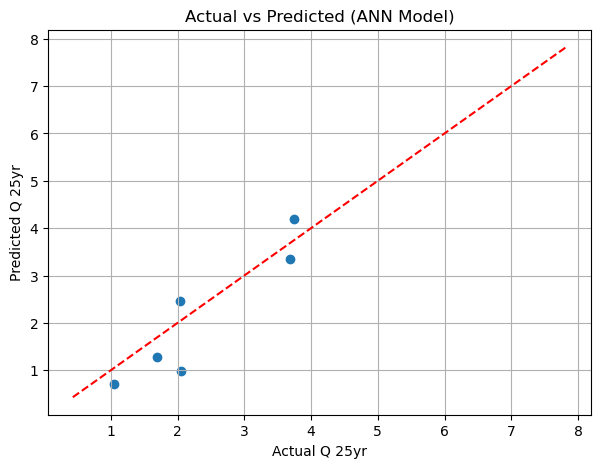

In [19]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Q 25yr")
plt.ylabel("Predicted Q 25yr")
plt.title("Actual vs Predicted (ANN Model)")
plt.grid(True)
plt.show()

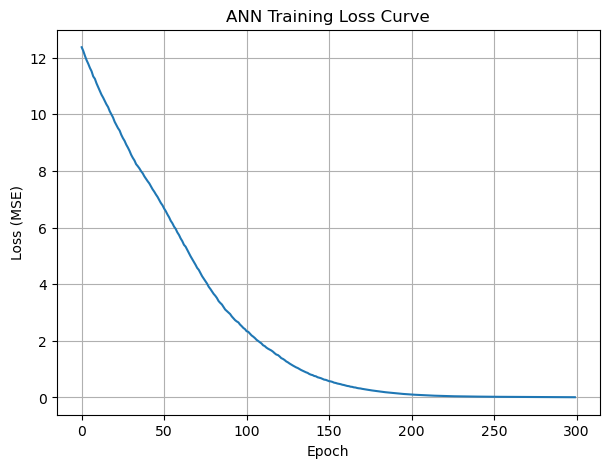

In [20]:
plt.figure(figsize=(7,5))
plt.plot(history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("ANN Training Loss Curve")
plt.grid(True)
plt.show()